# A6: A Brief Introduction to Surrogate Models

---

*Purpose*: With both the optimization and probability techniques we've discussed, you may have noticed that we need to evaluate our function *a lot* of times! If you had plans to do a project using some kind of external simulation software (e.g. FEA), you won't be able to call your function that many times. *However* you're not sunk, you just need one more tool: We will learn about *surrogate models* to stitch together Grama tools with external software using flexible machine learning techniques.

Ultimately, surrogate models will allow you to use what you learned in this class with *any* problem you encounter *for the rest of your career*.

*Learning Objectives*: By working through this assignment, you will 
- understand the basics about *gaussian processes*: conditional probability, kernel functions, predictive uncertainty
- apply cross-validation to tune hyperparameters
- fit gaussian processes as a surrogate model
- use gaussian processes to perform Bayesian optimization

*Reading*:
- (None required)
- (Optional) Rasmussen and Williams (2006), [freely available online](http://www.gaussianprocess.org/gpml/); See Chapter 2 for a very formal introduction to gaussian processes.
- (Optional, A far more accessible introduction to regression, doesn't cover GPs) Cassie Kozyrkov [Making Friends with Machine Learning: Regression](https://www.youtube.com/watch?v=WNvOtwP_yf4&list=PLluqivwOH1ouKkbM0c6x-g7DQnXF0UmC0&index=37)
- (Super optional, but super entertaining) Kristin Lennox, [All About that Bayes](https://www.youtube.com/watch?v=eDMGDhyDxuY&list=PLluqivwOH1ouKkbM0c6x-g7DQnXF0UmC0&index=22)



### Assignment Checklist

1. [?] Make sure you have answered all questions. These are marked with a **qX.Y**
1. [?] Make sure you complete the Project Task at the end of the assignment. These will scaffold your project progress during the semester.
1. [?] Make sure your notebook passes all `assert()` statements. You will not get full credit for the assignment if a single `assert()` fails.
1. [?] Make sure your notebook runs: `Kernel > Restart kernel and run all cells...`
1. [?] Upload your notebook to Canvas.


### Grading Rubric

Every assignment is worth 10 points; it is not possible to receive less than 0 points. For each question (qX.Y) on a given assignment, the following grading rubric will be applied. For every NI that you receive, one point will be subtracted from your assignment total. For reference, to receive an A- in this class, you will need an average of 9 points across your 5 best assignments, meaning you need to have at most one mistake on your final submission for 5 assignments. To achieve this, you should take advantage of both the Draft and Final submission deadlines.

| Category     | Needs Improvement (NI)                     | Satisfactory (S)                       |
|--------------|--------------------------------------------|----------------------------------------|
| Effort       | qX.Y left unattempted                      | qX.Y attempted                         |
| Assertions   | Code does not pass an `assert()`           | All `assert()`s pass, or no assertions |
| Observations | Any point under *observe* left unattempted | All *observe*s attempted and correct,  |
|              | Provided an incorrect observation          | or no *observe*s for that q            |


## S1: Surrogate Models and Gaussian Processes

---

The "big idea" behind a surrogate model is to replace an expensive-to-evaluate function $f(x)$ with an approximation $\hat{f}(x)$ that is cheap-to-evaluate. The expensive model might be a computer simulation, such as a FEA of a full car, a simulation of a large complicated circuit, etc. The general strategy to building an approximation $\hat{f}(x)$ is to first gather some limited number of evaluations $f(x_i)$ with the real simulation, and *fit* a model to those data.

There are many different kinds of surrogate model; we'll look at one particular class that is extremely useful and extremely common in practice: *gaussian processes*.


In [1]:
import grama as gr
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
DF = gr.Intention()
%matplotlib inline

# Set figure options
plt.rcParams['figure.figsize'] = [6, 4]
plt.rcParams['figure.dpi'] = 100 # 200 e.g. is really fine, but slower

A gaussian process *is* a random variable. It's a bit of a funny random variable because it's a *random field*, which is like a random vector, but (infinitely) bigger. The key idea with gaussian processes is to assume each function value $f(x)$ is distributed as a normal random variable $F(x) \sim N(\mu, \sigma^2)$, and that two function values $F(x), F(x')$ are *correlated*, which describes the function's structure.

### Conditional probability

We "train" or "fit" the gaussian process by using *conditional probability*, which relies on some kind of relation (e.g. correlation) to impose meaningful structure. We *condition on* an event related to a random variable; for instance if we have $[X, Y] \sim N(\mu, \Sigma)$, we could condition on the event $Y = 0.5$, which we write as $X | Y = 0.5$. We can then ask how $X$ is distributed *conditioned on* the event $X | Y = 0.5 \sim ???$.

The next code chunk illustrates a 2d gaussian with correlation, and highlights observations that (approximately) satisfy our event $Y = 0.5$.


eval_sample() is rounding n...
Estimated runtime: 0.0000 sec


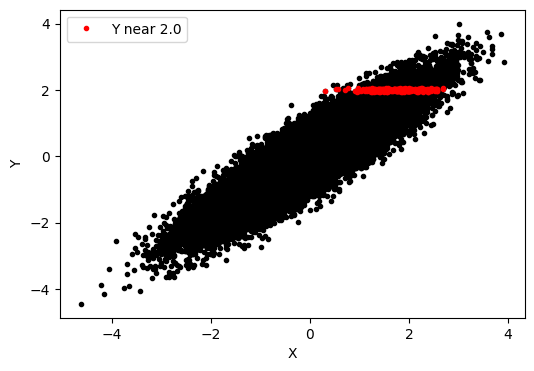

In [2]:
## NOTE: No need to edit; run and inspect
md_corr = (
    gr.Model()
    >> gr.cp_marginals(
        x=dict(dist="norm", loc=0, scale=1),
        y=dict(dist="norm", loc=0, scale=1),
    )
    >> gr.cp_copula_gaussian(df_corr=gr.df_make(
        var1=["x"],
        var2=["y"],
        corr=[0.9],
    ))
)

df_corr = (
    md_corr
    >> gr.ev_sample(n=5e4, seed=101, df_det="nom", skip=True)
    # y == 0.5 exactly will yield no observations, so let's take an approximate
    # slab near our condition of interest
    >> gr.tf_mutate(flag=(1.95 <= DF.y) & (DF.y <= 2.05))
)

## Visualize 2d
plt.figure()
plt.plot(df_corr.x, df_corr.y, "k.")
plt.plot(
    df_corr[df_corr.flag].x,
    df_corr[df_corr.flag].y,
    "r.",
    label="Y near 2.0"
)
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(loc=0)


### __q1.1__ Experiment with correlations

The following code filters correlated data to simulate a conditional variable. Test different values of correlation between `X, Y`, and answer the questions below.


eval_sample() is rounding n...
Estimated runtime: 0.0000 sec


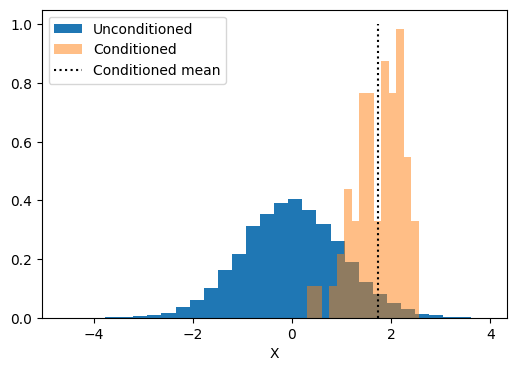

In [8]:
###
# TASK: Test the following code with different values of `corr`
###

# TODO: Test different correlation values
corr = 0.9


## NOTE: No need to edit
df_corr = (
    md_corr
    >> gr.cp_copula_gaussian(df_corr=gr.df_make(var1=["x"], var2=["y"], corr=[corr]))
    >> gr.ev_sample(n=1e4, seed=101, df_det="nom", skip=True)
    >> gr.tf_mutate(flag=(1.95 <= DF.y) & (DF.y <= 2.05))
)

## Visualize histograms
plt.figure()
plt.hist(df_corr.x, bins=30, density=True, label="Unconditioned")
plt.hist(df_corr[df_corr.flag].x, bins=15, alpha=1/2, density=True, label="Conditioned")
plt.plot(
    [df_corr[df_corr.flag].x.mean()]*2,
    [0, 1.0],
    "k:",
    label='Conditioned mean'
)
plt.xlabel("X")
plt.legend(loc=0)


*Observe*:

- What shape does the conditioned distribution $X | Y \approx 2.0$ have?
  - The conditioned distribution with a correlation of 0.0 looks close to a normal distribution, centered on 0 and spreading a little further on the left side.

Test at `corr = 0.5` and `corr = 0.9` and fill in the following table:

| Question | Case `corr = 0.5` | Case `corr = 0.9` |
|---|---|---|
| How "narrow" is the `Conditioned` distribution? | about 4 'X' units | about 2 'X' units | 
| Where does the `Conditioned mean` tend to land? | 0.8 | 0.9ish |



The key ingredients behind *conditioning* are that:

- We have multiple random variables, one (or more) of which we *fix* to a specified value
- We have a *defined relationship* between those variables, for instance a correlation between two, or a more complicated *covariance structure* between more variables

These key ideas come together in a *gaussian process*.


### A tour of Gaussian Processes

The key idea behind a gaussian process is to use an infinite collection of gaussian random variables to represent each individual function value. We call a single random scalar $X$ a random variable, a stacked-set of random scalars $[X_i]$ a random vector, and a random function $F(x)$ a random process. We notate a gaussian process via

$$F(x) \sim GP(\mu(x), \Sigma(x, x'))$$

where $\mu(x)$ is the mean *function*, and $\Sigma(x, x')$ is the *covariance structure*. Both of these are directly analogous to the mean and covariance of a random vector, but are "larger" objects since they describe random functions.

The key idea behind a gaussian process is that we will model some unknown function as a random process, obtain data on the function at specified points $x_i$ to fix specific function values $F(x_i)$, collect those evaluations into a dataset $\{F(x_i)\}_{i=1}^n$, and *condition* on that dataset $\hat{F}(x) \equiv F(x) \,|\, \{F(x_i)\}_{i=1}^n$ to make predictions on unobserved function values.

Let's go through a specific example. The following code loads gaussian process fitting tools:


In [9]:
## NOTE: No need to edit;
# This imports the gaussian process fitting routine
from grama.fit import ft_gp, fit_gp
from sklearn.gaussian_process.kernels import ConstantKernel, RBF


The `fit_gp` routines from Grama wrap tools from the scikit-learn package; we'll use the `ConstantKernel` and `RBF` functions later to design a specific covariance structure $\Sigma(x, x')$.

To illustrate how a gaussian process works, let's first write down some data:


Text(0, 0.5, 'y')

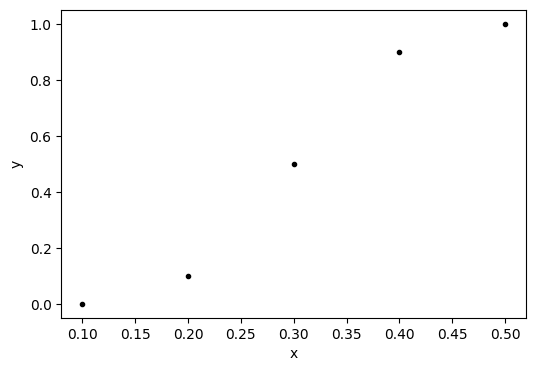

In [10]:
## NOTE: No need to edit
# Create data
df_example = gr.df_make(
    x=[0.1, 0.2, 0.3, 0.4, 0.5],
    y=[0.0, 0.1, 0.5, 0.9, 1.0],
)

# Visualize
plt.plot(df_example.x, df_example.y, "k.")
plt.xlabel("x")
plt.ylabel("y")


We can use the `ft_gp()` routine to fit a gaussian process and make predictions. The following code "fits" a gaussian process by taking the data, computes a conditional GP based on the observed function values, and makes predictions by computing the mean of the conditioned gaussian process $\mathbb{E}[\hat{F}(x)]$. Since the GP is a random variable, we can also create *uncertainty intervals* around the mean function by using the standard deviation $\sqrt{\mathbb{V}[\hat{F}(x)]}$.

The following code visualizes the fitted GP.


Text(0, 0.5, 'y')

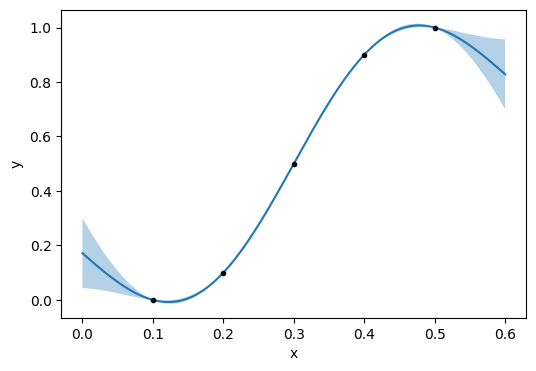

In [11]:
## NOTE: No need to edit
# Fit a GP
md_ex = (
    df_example
    >> ft_gp(
        var=["x"], 
        out=["y"],
        ## Specify a correlation structure via a `kernel`
        kernels=RBF(length_scale=1.0)
    )
)

df_x = gr.df_make(x=np.linspace(0, 0.6, num=500))
df_ex = (
    md_ex
    >> gr.ev_df(df=df_x)
    >> gr.tf_mutate(
        ymin=DF.y_mean - 2 * DF.y_sd,
        ymax=DF.y_mean + 2 * DF.y_sd,
    )
)

# Visualize
plt.fill_between(df_ex.x, df_ex.ymin, df_ex.ymax, alpha=1/3)
plt.plot(df_ex.x, df_ex.y_mean)
plt.plot(df_example.x, df_example.y, "k.")
plt.xlabel("x")
plt.ylabel("y")


### __q1.2__ Make a prediction

Imagine you were to extend the domain of evaluation to $x \in [-2, +2]$; what do you think the function will look like?

- I think the ends would keep going in their current end directions - maybe it start oscillating again if it's using a sin/cos function, but somehow I don't think that's the case. I think the uncertainty line will keep increasing. 

Once you've written down a prediction, evaluate the gaussian process `md_ex` from $x \in [-2, +2]$. Compare your prediction at *Observe* below.


Text(0, 0.5, 'y')

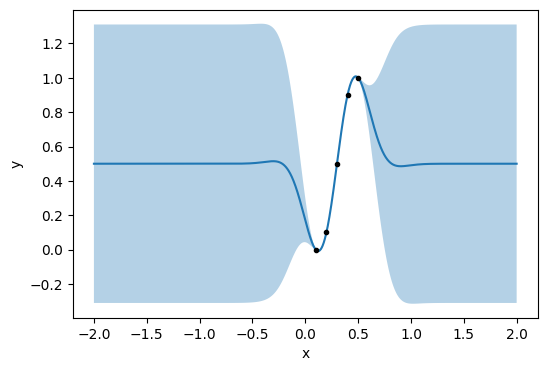

In [12]:
###
# TASK: Evaluate the model md_ex from x \in [-2, +2]
###
df_x_wide = gr.df_make(x=np.linspace(-2, 2, num=1500))
df_wide = (
    md_ex
    >> gr.ev_df(df=df_x_wide)
    >> gr.tf_mutate(
        ymin = DF.y_mean - 2 * DF.y_sd,
        ymax = DF.y_mean + 2 * DF.y_sd,
    )
)



## NOTE: No need to edit below
# Visualize
plt.fill_between(df_wide.x, df_wide.ymin, df_wide.ymax, alpha=1/3)
plt.plot(df_wide.x, df_wide.y_mean)
plt.plot(df_example.x, df_example.y, "k.")
plt.xlabel("x")
plt.ylabel("y")


*Observe*:

- How does the reality compare with what you predicted?
  - I guess I didn't expect the lines to go straight, but the overall idea fits what I was imagning.
- How do the uncertainty intervals (the lighter bands) behave as you move further from the data?
  - They expand in the x and y directions as you get more uncertainty in the points.


Generally, a gaussian process will make predictions by *interpolating* between the available data; our choice of kernel (defining the covariance structure $\Sigma(x, x')$ ensures the resulting curve is smooth. The kernel dictates the properties of the GP, so understanding how a kernel works is *criticall important* to successfully fitting a gaussian process.

The `RBF()` kernel is a *radial basis function*; it dictates a correlation between two function values $F(x), F(x')$ that is based on the distance between the two points in the input space $x, x'$. The scikit-learn `RBF()` is equivalent to

$$k(x, x') = \exp\left( - \frac{1}{2}\frac{\|x - x'\|_2^2}{l^2} \right)$$

The next exercise will help you interpret how this kernel behaves.


### __q1.3__ Interpret a kernel

The following code illustrates values of $k(x, x')$ at different distances between points $x, x'$ and lengthscale parameter $l$. Inspect the results and answer the questions below.


In [ ]:
###
# TASK: Run the following code; inspect the results, answer the questions below
###

## NOTE: No need to edit
# Define the RBF correlation structure
md_sq_exponential = (
    gr.Model()
    >> gr.cp_vec_function(
        fun=lambda df: gr.df_make(
            s=np.exp(-0.5 * df.d**2 / df.l**2)
        ),
        var=["d", "l"],
        out=["s"],
    )
)

# Generate data
df_cov = (
    md_sq_exponential
    >> gr.ev_df(
        df=gr.df_make(d=np.linspace(0, 10))
        >> gr.tf_outer(gr.df_make(l=[0.1, 1.0, 10.0]))
    )
)

# Visualize
plt.plot(
    df_cov.d[df_cov.l == 0.1], 
    df_cov.s[df_cov.l == 0.1],
    "r",
    label="l = 0.1",
)
plt.plot(
    df_cov.d[df_cov.l == 1.0], 
    df_cov.s[df_cov.l == 1.0],
    "b",
    label="l = 1.0",
)
plt.plot(
    df_cov.d[df_cov.l == 10.0], 
    df_cov.s[df_cov.l == 10.0],
    "g",
    label="l = 10.0",
)
plt.legend(loc=0)
plt.xlabel("Distance between points")
plt.ylabel("Correlation")

*Observe*:

- Which value of $l$ has the highest correlation at longer distances?
  - (Your response here)
- Which value of $l$ has the smallest correlation at longer distances?
  - (Your response here)
- In your own words, how can you interpret the hyperparameter $l$ in terms of the correlation created by the kernel model above?
  - (Your response here)


The previous exercise illustrates how the *correlation* between function values changes with distance and the *lengthscale parameter* $l$. The next exercise will have you connect these observations to fitted GP's.


### __q1.4__ Compare models across lengthscales

Run the following code, inspect the results, and answer the questions below.


In [ ]:
###
# TASK: Run the following code; inspect and answer the questions below
###

## NOTE: No need to edit
# Define three GP's with different lengthscales
md_ex1 = (
    df_example
    >> ft_gp(
        var=["x"],
        out=["y"],
        kernels=RBF(1e-0, length_scale_bounds="fixed"),
    )
)

md_ex2 = (
    df_example
    >> ft_gp(
        var=["x"],
        out=["y"],
        kernels=RBF(1e-1, length_scale_bounds="fixed"),
    )
)

md_ex3 = (
    df_example
    >> ft_gp(
        var=["x"],
        out=["y"],
        kernels=RBF(1e-2, length_scale_bounds="fixed"),
    )
)

## Evaluate each GP
df_ex1 = (
    md_ex1
    >> gr.ev_df(df=df_x)
    >> gr.tf_mutate(
        ymin=DF.y_mean - 2 * DF.y_sd,
        ymax=DF.y_mean + 2 * DF.y_sd,
    )
)

df_ex2 = (
    md_ex2
    >> gr.ev_df(df=df_x)
    >> gr.tf_mutate(
        ymin=DF.y_mean - 2 * DF.y_sd,
        ymax=DF.y_mean + 2 * DF.y_sd,
    )
)

df_ex3 = (
    md_ex3
    >> gr.ev_df(df=df_x)
    >> gr.tf_mutate(
        ymin=DF.y_mean - 2 * DF.y_sd,
        ymax=DF.y_mean + 2 * DF.y_sd,
    )
)

# Visualize
fig, (ax1, ax2, ax3) = plt.subplots(3, 1)
ax1.fill_between(df_ex1.x, df_ex1.ymin, df_ex1.ymax, alpha=1/3)
ax1.plot(df_ex1.x, df_ex1.y_mean, label="l = 1.0")
ax1.plot(df_example.x, df_example.y, "k.")
ax1.legend(loc=0)

ax2.fill_between(df_ex2.x, df_ex2.ymin, df_ex2.ymax, alpha=1/3)
ax2.plot(df_ex2.x, df_ex2.y_mean, "r", label="l=0.1")
ax2.plot(df_example.x, df_example.y, "k.")
ax2.legend(loc=0)

ax3.fill_between(df_ex3.x, df_ex3.ymin, df_ex3.ymax, alpha=1/3)
ax3.plot(df_ex3.x, df_ex3.y_mean, "y", label="l=0.01")
ax3.plot(df_example.x, df_example.y, "k.")
ax3.legend(loc=0)

plt.xlabel("x")
plt.ylabel("y")


*Observe*:

- What is the difference between the fitted value `y_mean` (solid curve) and the measured value `y` **at** each sample (each point)? Does this vary across the gaussian processes?
  - (Your response here)
- How does `y_mean` (solid curve) behave *between* the observed data? How does this vary across values of lengthscales?
  - (Your response here)
- How do the $\pm2 \sigma$ bounds (the shaded ribbon between points) vary across the domain? How do these trends differ across the different values of $l$?
  - (Your response here)


From these two exercises, we can see that: 

> The covariance structure $\Sigma(x, x')$, defined by a `kernel`, is critically important for defining a gaussian process's behavior.

> Any given `kernel` is defined by some parameters, such as a lengthscale $l$.

Quantities such as lengthscale that we fix before training are called [hyperparameters](https://en.wikipedia.org/wiki/Hyperparameter_(machine_learning)), and one of our key tasks in fitting a GP is to tune the hyperparameters.

We need a *principled way* to pick hyperparameter values in order to successfully fit a gaussian process. One way we could do this is to use ideas from nonlinear least squares (NLS); to define an error metric based on the predicted $\mathbb{E}[\hat{F}(x_i)]$ and actual $F(x_i)$ function values. However, we'll see that a naive application of this idea will lead to terrible results!


### __q1.5__ Estimating error the **wrong** way

Fit two gaussian processes, one with a very long lengthscale, and one with a very short lengthscale. Compare their results, and answer the questions below.

Note that `NDME` stands for non-dimensional model error; it is a dimensionless measure of model accuracy defined by

$$\text{NDME} = \sqrt{\frac{\text{MSE}}{\sigma^2}},$$

where $\sigma^2$ is the variance of the predicted quantity.


In [ ]:
###
# TASK: Fit two GP's, compare their errors
###

## NOTE: No need to edit; this creates the data to fit
df_sine = (
    gr.df_make(x=np.linspace(0, 1, num=50))
    >> gr.tf_mutate(y=gr.sin(2 * np.pi * DF.x))
)

# md_fit1 = ??? # Fit with a long correlation length l
# md_fit2 = ??? # Fit with a short correlation length l


## NOTE: No need to edit; use this to check your work
df_err1 = (
    md_fit1
    >> gr.ev_df(df=df_sine)
    >> gr.tf_summarize(ndme=gr.ndme(DF.y_mean, DF.y))
)
df_err2 = (
    md_fit2
    >> gr.ev_df(df=df_sine)
    >> gr.tf_summarize(ndme=gr.ndme(DF.y_mean, DF.y))
)

assert(df_err1.ndme[0] < 1e-6)
assert(df_err2.ndme[0] < 1e-6)
print("Success!")
print("NDME1 = {0:4.3e}".format(df_err1.ndme[0]))
print("NDME2 = {0:4.3e}".format(df_err2.ndme[0]))

df_fit1 = gr.eval_df(md_fit1, df=gr.df_make(x=np.linspace(0, 1, num=1000)))
df_fit2 = gr.eval_df(md_fit2, df=gr.df_make(x=np.linspace(0, 1, num=1000)))

# Visualize
plt.plot(df_sine.x, df_sine.y, "k.")
plt.plot(df_fit1.x, df_fit1.y_mean, label="Model 1")
plt.plot(df_fit2.x, df_fit2.y_mean, label="Model 2")
plt.legend(loc=0)


*Observe*:

- Visually, how well does your long correlation length $l_1$ model fit the data?
  - (Your response here)
- Visually, how well does your short correlation length $l_2$ model fit the data?
  - (Your response here)
- Quantitatively, how do the model mean square errors `NDME` compare when evaluating with `df_sine`?
  - (Your response here)
- Suppose you wanted to set the correlation length $l$ by optimizing over the mean squared error `NDME` using the quantitative approach above. Would this approach be successful? Why or why not?
  - (Your response here)


### Estimating Error with Cross Validation

The key issue with estimating error like we did above is that we are *evaluating* the model on the same data used to *train* the model. This leads to an overly-optimistic assessment of model accuracy. A simple way to fix this is to use a test-train split. One of the most common kinds of splitting is k-folds cross validation. The following figure illustrates the procedure:

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/b/b5/K-fold_cross_validation_EN.svg/1280px-K-fold_cross_validation_EN.svg.png" style="background-color:white;" />

Image credit: [By Gufosowa - Own work, CC BY-SA 4.0](https://commons.wikimedia.org/w/index.php?curid=82298768)

By repeatedly training the model on different subsets of the data and testing on a *distinct* subset, we can estimate a far less biasted metric of model accuracy. The Grama routine `tran_kfolds()` performs k-fold cross validation on a given dataset, using a given model. You can test different hyperparameter values within this framework. This will help us select reasonable values for hyperparameters. 

*Note*: The following code takes advantage of [partial evaluation](https://en.wikipedia.org/wiki/Partial_evaluation) with the `ft_gp` routine. This allows you to set the hyperparameters for the model, but delay fitting it until later. Think of this like a "recipe" that you pass to `tran_kfolds()`, which in turn applies your fitting recipe to different subsets of the data.


In [ ]:
## NOTE: No need to edit; this performs k-fold cross validation
# Perform k-fold cross validation
df_cv1 = (
    df_sine
    >> gr.tf_kfolds(
        # Set number of folds
        k=5, 
        # Provide a fitting "recipe"
        ft=ft_gp(var=["x"], out=["y"], kernels=RBF(1e-1, length_scale_bounds="fixed")), 
        # Specify the output to test
        out=["y"],
        # Specify the error metrics to compute
        summaries=dict(ndme=gr.ndme),
    )
)
# Compare a second correlation length
df_cv2 = (
    df_sine
    >> gr.tf_kfolds(
        k=5, 
        ft=ft_gp(var=["x"], out=["y"], kernels=RBF(1e-3, length_scale_bounds="fixed")), 
        out=["y"],
        summaries=dict(ndme=gr.ndme),
    )
)

# Print the results
print("df_cv1 =\n{}".format(df_cv1))
print("df_cv2 =\n{}".format(df_cv2))

Note that we now have an error estimate for each independent fold. Crucially, this approach reveals that the smaller correlation length has an abysmal error, while the larger correlation length results in a highly accurate model.


### __q1.6__ Do a hyperparameter search

Complete the code below to perform kfolds cross validation with a selection of different hyperparameter values. Answer the questions below.

*Hint*: Test *just enough* values of `l` to get a sense of the behavior---repeated cross-validation can be expensive. You should be able to find a curve with an approximate minimum.


In [ ]:
###
# TASK: Perform k-folds cross validation on df_sine using a GP, testing different
#       correlation lengths. Answer the questions below.
###

## NOTE: No need to edit the support code, just complete the marked lines below
df_cv_all = pd.DataFrame()

## TASK: Decide what values of `l` to test
# l_all = [???]


# Iterate over each correlation length
for l in l_all:
    ## TASK: Perform k-fold cross validation
    # df_cv = ???


    # Record the results
    df_cv_all = (
        df_cv_all
        >> gr.tf_bind_rows(df_cv >> gr.tf_mutate(l=l))
    )
    
## NOTE: No need to edit; use this to check your work
df_cv_summary = (
    df_cv_all
    >> gr.tf_group_by("l")
    >> gr.tf_summarize(
        ndme_mu=gr.median(DF.ndme_y),
        ndme_lo=gr.quant(DF.ndme_y, p=0.25),
        ndme_hi=gr.quant(DF.ndme_y, p=0.75),
    )
)

plt.fill_between(df_cv_summary.l, df_cv_summary.ndme_lo, df_cv_summary.ndme_hi, alpha=1/3)
plt.plot(df_cv_summary.l, df_cv_summary.ndme_mu)
plt.plot(df_cv_all.l, df_cv_all.ndme_y, "k.", markersize=1)
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-3, 1e+1)
plt.xlabel("Hyperparameter l (-)")
plt.ylabel("Error metric")


*Observe*:

- Where---approximately---does the minimum-CV error hyperparameter value `l` lie?
  - (Your response here)
- I chose to report both the median and quartiles of the CV results. What source of randomness leads to the scatter in the CV results?
  - (Your response here)


### Closing note: Other hyperparameter approaches

There are other approaches to finding optimal hyperparameter values. A common approach with gaussian approaches is to maximize the *marginal likelihood*; a quantity related to how likely our dataset is to occur, given the tested values of the hyperparameters. This approach is built-into scikit-learn, and is the method employed when you provide bounds for a hyperparameter. The following code chunk demonstrates the approach.

*Note* For more details, see Rasmussen and Williams (2006), Ch. 5.


In [ ]:
## NOTE: No need to edit
# Find hyperparameter value by maximizing the marginal likelihood
md_marglik = (
    df_sine
    >> ft_gp(var=["x"], out=["y"], kernels=RBF(1e-1, length_scale_bounds=(1e-3, 1e+1)))
)
md_marglik.printpretty() 


The optimized `length_scale` is similar to what I found using cross-validation above.


## S2: Application of Surrogates: Bayesian Optimization

---

Surrogate models---such as a gaussian process---have many uses. We'll explore one in this last section: *Bayesian optimization* (BO). This procedure is best illustrated with an example. Imagine we had some function we want to optimize, but the model is so computationally expensive that we can only afford to run the model a handful of times. For instance:


In [ ]:
## NOTE: No need to edit; run and inspect
# Set up a "true" model to optimize
md_true = (
    gr.Model()
    >> gr.cp_vec_function(
        fun=lambda df: gr.df_make(
            y=-np.cos(2 * np.pi * df.x) + df.x**2
        ),
        var=["x"],
        out=["y"],
    )
    >> gr.cp_bounds(x=(-2, +2))
)

# Generate a small set of evaluations of the true model
df_round_ex = (
    md_true
    >> gr.ev_df(df=gr.df_make(x=[-2, -1.05, -0.5, +0.3, +2]))
)

# Visualize
df_sweep_ex = gr.eval_df(
    md_true,
    df=gr.df_make(x=np.linspace(-2, +2, num=200))
)

plt.plot(df_sweep_ex.x, df_sweep_ex.y)
plt.plot(df_round_ex.x, df_round_ex.y, "k.", markersize=10)
plt.xlabel("X")
plt.ylabel("Y")

The idea behind Bayesian optimization is to fit a gaussian process to our limited data, and to do optimization *on the surrogate model* to inform which points to try evaluating with the true model next. The first question we need to tackle is how to best utilize the information from our GP, which includes both a mean prediction and uncertainty information. The next task will have you compare a couple different *acquisition strategies* on how to make a candidate selection.


### __q2.1__ Compare acquisition strategies

Our goal is to minimize the function above, but we only have limited data (the black points). The following code fits a gaussian process and applies different *acquisition strategies* to select new candidates to try. Run the code, inspect the results, and answer the questions below.


In [ ]:
###
# TASK: Run the following code; inspect the results and answer the questions below
###

## NOTE: No need to edit; run and inspect
md_fit_ex = (
    df_round_ex
    >> ft_gp(
        var=["x"],
        out=["y"],
        kernels=ConstantKernel(1.0, (1e-3, 1e3)) 
               *RBF(10, (1e-1, 1e2)),
        n_restart=5,
    )
    >> gr.cp_vec_function(
        fun=lambda df: gr.df_make(
            ymin=df.y_mean - 2 * df.y_sd,
            ymax=df.y_mean + 2 * df.y_sd,
        ),
        var=["y_mean", "y_sd"],
        out=["ymin", "ymax"],
    )
    >> gr.cp_bounds(x=(-2, +2))
)

df_sweep_fit = gr.eval_df(
    md_fit_ex, 
    df=gr.df_make(x=np.linspace(-2, +2, num=200))
)

## NOTE: This will be particularly useful example code;
# here I compute a few different acquisition strategies
# ---------------------------------------------
# Best mean performance
df_opt_ex0 = (
    md_fit_ex
    >> gr.ev_min(out_min="y_mean", n_restart=5)
    >> gr.tf_arrange(DF.y_mean)
    >> gr.tf_head(1)
)
# Best lower-bound performance
df_opt_ex1 = (
    md_fit_ex
    >> gr.ev_min(out_min="ymin", n_restart=5)
    >> gr.tf_arrange(DF.ymin)
    >> gr.tf_head(1)
)
# Largest uncertainty
df_opt_ex2 = (
    md_fit_ex
    >> gr.cp_vec_function(
        fun=lambda df: gr.df_make(
            out_max_u=-df.y_sd
        ),
        var=["y_sd"],
        out=["out_max_u"],
    )
    >> gr.ev_min(out_min="out_max_u", n_restart=5)
    >> gr.tf_arrange(DF.out_max_u)
    >> gr.tf_head(1)
)
# ---------------------------------------------

# Visualize
plt.plot(df_sweep_ex.x, df_sweep_ex.y, ":")
plt.fill_between(
    df_sweep_fit.x, 
    df_sweep_fit.ymin, 
    df_sweep_fit.ymax, 
    alpha=1/2,
)
plt.plot(df_sweep_fit.x, df_sweep_fit.y_mean, "k", linewidth=1)
plt.plot(df_round_ex.x, df_round_ex.y, "k.", markersize=10)
plt.plot(df_opt_ex0.x, df_opt_ex0.ymin, ".", markersize=10, label="Mean")
plt.plot(df_opt_ex1.x, df_opt_ex1.ymin, ".", markersize=10, label="Lower bound")
plt.plot(df_opt_ex2.x, df_opt_ex2.ymin, ".", markersize=10, label="Max SD")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(loc=0)


*Observe*

- Would the `Mean` acquisition candidate be a good next case to check with a limited computational budget? Why or why not?
  - (Your response here)
- Describe in words where the `Lower bound` acquisition function decided to go. Describe in terms of the uncertainty bounds of the gaussian process.
  - (Your response here)
- Does the `Lower bound` acquisition function exhibit multiple local minima? (yes or no)
  - (Your response here)
- Describe in words where the `Max SD` acquisition function decided to go. Describe in terms of the uncertainty bounds of the gaussian process.
  - (Your response here)
- Did *any* of the proposed candidates land nearer the global optimum of the true function? (The dashed line)
  - (Your response here)


Using a Bayesian optimization strategy *does not guarantee* that we will find the global minimum in a single round. Rather, the power of the approach is to make principled choices about where to search next. The following code selects a few of the "Lower bound" candidates to evaluate. We will see that the the predicted values will not tend to match the actual values, but we will gain more information about the true function in regions that are promising.


In [ ]:
## NOTE: No need to edit; run and inspect the results

# Note: This grabs the best lower-bound performers; I'm
# actually *relying* on getting caught in multiple minima
# to get a selection of different candidates
df_bo_ex = (
    md_fit_ex
    >> gr.ev_min(out_min="ymin", n_restart=5, seed=104)
    # Reveal the true values
    >> gr.tf_md(md=md_true)
)

# Re-fit the model with new data
md_bo_ex = (
    # Combine old and new data
    df_round_ex
    >> gr.tf_bind_rows(df_bo_ex)
    # Re-fit the model
    >> ft_gp(
        var=["x"],
        out=["y"],
        kernels=ConstantKernel(1.0, (1e-3, 1e3)) 
               *RBF(10, (1e-1, 1e2)),
        n_restart=5,
    )
    # Construct the uncertainty bounds
    >> gr.cp_vec_function(
        fun=lambda df: gr.df_make(
            ymin=df.y_mean - 2 * df.y_sd,
            ymax=df.y_mean + 2 * df.y_sd,
        ),
        var=["y_mean", "y_sd"],
        out=["ymin", "ymax"],
    )
    >> gr.cp_bounds(x=(-2, +2))
)

# Visualize
df_bo_sweep = gr.eval_df(
    md_bo_ex, 
    df=gr.df_make(x=np.linspace(-2, +2, num=200))
)

plt.plot(df_sweep_ex.x, df_sweep_ex.y, ":")
plt.fill_between(
    df_bo_sweep.x, 
    df_bo_sweep.ymin, 
    df_bo_sweep.ymax, 
    alpha=1/2,
)
plt.plot(df_bo_sweep.x, df_bo_sweep.y_mean, "k", linewidth=1, label="Re-fit model")
plt.plot(df_round_ex.x, df_round_ex.y, "k.", markersize=10)
plt.plot(df_bo_ex.x, df_bo_ex.ymin, ".", markersize=10, label="Round 1, pred")
plt.plot(df_bo_ex.x, df_bo_ex.y, ".", markersize=10, label="Round 1, actual")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(loc=0)


Note that the uncertainty bands have "collapsed" at each new measured value. The minimum lower bound was not near the global optimum, but one of the other local minima was. Note that we're __not__ guaranteed to find the global optimum in a single round of optimization, but in this scenario we got lucky!


### Bayesian Optimization, in a nutshell

Procedure:

1. Obtain and inspect data on inputs and responses
2. Fit a GP with all available data to predict responses at new input values
3. Optimize the *fitted* model to select new input settings
4. Gather response data for selected input settings; inspect
5. Repeat from (2) until satisfied


## Revenge of the Boats

Let's apply the ideas of Bayesian optimization to boat hull design. I've written a set of tools to help design and analyze 2d boat sections:


In [ ]:
from boat_utils import *


### Boat Hulls and the AVS

If you took QEA, you might remember that a boat can have a "tipping point": As we rotate a boat along its long axis, it can reach an *angle of vanishing stability* (AVS) and flip over. Designing a boat to have a large AVS is a key design criterion for boat hull design.

The following code generates a boat hull based on a few parameters. Note that the boat has ballast in its keel; the lower portion of the boat is heavier to lower the center of mass.


In [ ]:
## NOTE: No need to edit
# Define boat hull
w_k = 0.3 # Curve of keel
h_k = 0.8 # Height of keel
w_h = 4.0 # Curve of hull

# Generate hull
df_hull, df_mass = make_hull([w_k, h_k, w_h])

# Visualize
plt.plot(
    df_hull[df_hull.dm < 1e-4].x, 
    df_hull[df_hull.dm < 1e-4].y, 
    ".",
    label="Light"
) 
plt.plot(
    df_hull[df_hull.dm >= 1e-4].x, 
    df_hull[df_hull.dm >= 1e-4].y, 
    ".",
    label="Heavy"
) 
plt.xlabel("Width (in)")
plt.ylabel("Height (in)")
plt.legend(loc=0)


We can compute a moment curve to help determine the AVS of this boat:


In [ ]:
## NOTE: No need to edit
df_res = get_moment_curve(df_hull, df_mass)
df_avs = get_avs(df_hull, df_mass)


Visualize the moment curve:


In [ ]:
## NOTE: No need to edit
print(df_avs)
plt.plot(
    [df_res.angle.min(), df_res.angle.max()],
    [0, 0],
    "k:"
)
plt.plot(
    df_res.angle,
    df_res.M_net
)
plt.plot(df_avs.angle, [0], "k.")
plt.xlabel("Heel angle (radians, CCW from neutral)")
plt.ylabel("Net moment (lbf-in)")


Based on the coordinate system, M_net going negative is a righting moment for a positive angle (counter-clockwise rotation from horizontal `angle == 0`).

This boat design has an *angle of vanishing stability* (AVS) around `angle == 1.7` (in radians). This is indicated by the moment curve crossing zero from negative-to-positive. If the boat is rotated beyond this point, its net moment will tend to further rotate the boat such that its deck will lay underwater. The boat will then approach its other stable angle, which is to lie upside-down!


### Goal: Design for a specified AVS

Design a boat with a specified AVS between `[120, 140]` degrees (`[2.09, 2.44]` radians). We'll approach this design problem using Bayesian optimization, and will break it down into a few steps.


### __q2.2__ Pick a design space

Create a model `md_dv` with a distribution for the design variables. You can use independent uniform distributions over "reasonable" bounds, or design your own more complicated distribution. You can use the boat hull code above to test a range of values to help determine reasonable bounds. You'll use your model below to draw samples to define a training data set.


In [ ]:
###
# TASK: Create a model to define a design space for your boat study;
#       make sure it provides a well-defined distribution.
###

# md_dv = ???


## NOTE: No need to edit; use this to test your work
gr.eval_sample(md_dv, n=1, skip=True)
md_dv.printpretty()

### __q2.3__ Evaluate an initial batch of candidates

Draw 10 samples from your `md_dv` as an initial batch of candidates. Run the code and answer the questions below.

*Aside*: The scaffolding code below adds a unique identifier `uid` and round number `rnd` to each sample. We'll use these below to reliably *join* data sources together. This is the kind of approach you should take to help track cases in your own practice!


In [ ]:
###
# TASK: Draw 10 samples from your md_dv; the following
#       code will run a boat AVS analysis on each design.
#       Answer the questions below.
###

## REALLY important to fix a seed for both MC and SP!!!
seed0 = 101
n = 10

df_doe0 = (
    md_dv
    ## TODO: Draw 10 samples

    ## NOTE: No need to edit; this adds unique identification to each sample
    >> gr.tf_mutate(uid=DF.index, rnd=0)
)

## NOTE: No need to edit; this will run an AVS analysis
#        on each design
df_res0 = pd.DataFrame()
for i in range(df_doe0.shape[0]):
    df_hull_tmp, df_mass_tmp = make_hull([
        df_doe0.iloc[i].w_k, 
        df_doe0.iloc[i].h_k, 
        df_doe0.iloc[i].w_h,
    ])
    
    df_tmp = get_avs(df_hull_tmp, df_mass_tmp)
    df_tmp["uid"] = df_doe0.iloc[i].uid
    df_tmp["rnd"] = df_doe0.iloc[i].rnd
    
    df_res0 = pd.concat((df_res0, df_tmp), axis=0)

df_res0


*Observe*:

- How many of the computations failed? How can you tell?
  - (Your response here)
- Can you link the failed computations to the input variables with these results? Why or why not?
  - (Your response here)


### Inspect the Data: Failed computations


The following code "joins" the candidate and result DataFrames on the columns `uid, rnd`. This ensures that the correct results are "matched" as we combine datasets.


In [ ]:
## NOTE: No need to edit; this will join and print the results
df_both0 = (
    df_doe0
    >> gr.tf_inner_join(df_res0, by=["uid", "rnd"])
)
df_both0


We could look at the input variable levels, but it's easier to inspect more detailed results.


### __q2.4__ Inspect the failed runs

Filter the result dataset `df_both0` down to those cases that "failed". Inspect their moment curves and answer the questions below.


In [ ]:
###
# TASK: Filter df_both0 for only those cases that failed
# HINT: The function gr.is_nan() will give a Boolean indicating
#       True when its argument is NaN
###

# df_fail0 = ???


## NOTE: No need to edit; this will iterate over the failed cases and generate moment curves
#        for each case
df_fail_hulls0 = pd.DataFrame()
df_fail_moments0 = pd.DataFrame()
for i in range(df_fail0.shape[0]):
    df_hull_tmp, df_mass_tmp = make_hull([
        df_fail0.iloc[i].w_k, 
        df_fail0.iloc[i].h_k, 
        df_fail0.iloc[i].w_h,
    ])
    df_hull_tmp["uid"] = df_fail0.iloc[i].uid
    df_hull_tmp["rnd"] = df_fail0.iloc[i].rnd
    
    df_res_tmp = get_moment_curve(df_hull_tmp, df_mass_tmp)
    df_res_tmp["uid"] = df_fail0.iloc[i].uid
    df_res_tmp["rnd"] = df_fail0.iloc[i].rnd
    
    df_fail_hulls0 = pd.concat((df_fail_hulls0, df_hull_tmp), axis=0)
    df_fail_moments0 = pd.concat((df_fail_moments0, df_res_tmp), axis=0)
    
## Visualize
plt.plot(
    [df_fail_moments0.angle.min(), df_fail_moments0.angle.max()],
    [0, 0],
    "k:"
)
for i in range(df_fail0.shape[0]):
    plt.plot(
        df_fail_moments0[df_fail_moments0.uid == df_fail0.iloc[i].uid].angle,
        df_fail_moments0[df_fail_moments0.uid == df_fail0.iloc[i].uid].M_net,
        label="uid: " + str(df_fail0.iloc[i].uid),
    )
plt.legend(loc=0)    
plt.xlabel("Heel angle (radians, CCW from neutral)")
plt.ylabel("Net moment (lbf-in)")


*Observe*:

- What do you notice about the moment curves for the cases that "failed"?
  - (Your response here)
- Do these cases have a well-defined AVS? Why or why not?
  - (Your response here)


All of the cases with missing / "bad" values for `angle` will not be usable for modeling. To that end, we'll replace all the missing values with a reasonable "filler" value based on what you observed above.


### __q2.5__ Assign placeholder values

Use the function `gr.fillna()` with a call to `gr.tf_mutate()` to replace the failed computation AVS values with a reasonable "filler" value. Use your insights from q2.4 to set this filler value.

*Hint*: Remember to use `Shift + Tab` to look up documentation for a new function! 


In [ ]:
###
# TASK: Replace missing values of `angle` with a reasonable "filler" value
### 

# df_proc0 = ???


df_proc0

### __q2.6__ Fit a model

Design a gaussian process to fit the training data `df_proc0`. You should provide your model definition as `ft_gp_boat`, and the code below will run 5-fold cross validation to estimate the error. You can use this CV code to tune the model hyperparameters. Answer the questions below.

*Hint*: Remember that the code under the **Estimating Error with Cross Validation** section showed how to define a gaussian process `ft` to pass to `gr.tran_kfolds()`.

*Remember*: For Bayesian optimization, we don't need a model that's *perfect*. We just need a model that's *good enough*.


In [ ]:
###
# TASK: Provide a gaussian process (with hyperparameter choices) in ft_gp_boat
#       Adjust the hyperparameters, and answer the questions below.
###

# ft_gp_boat = ft_gp()


## NOTE: No need to edit; use this to check & inspect your work
# Check that your model only uses reasonable variables:
md_test = df_proc0 >> ft_gp_boat()
try:
    assert(len(set(md_test.var).difference({"h_k", "w_k", "w_h"})) == 0)
except AssertionError:
    raise ValueError("Invalid variable used! Make sure your model uses h_k, w_k, w_h only")

# Run k-folds CV to assess your model
df_kfolds = pd.DataFrame()
for seed in range(100, 120):
    df_ktmp = (
        df_proc0
        >> gr.tf_kfolds(
            ft=ft_gp_boat,
            k=5,
            out=["angle"],
            summaries=dict(ndme=gr.ndme),
            seed=seed,
        )
    )
    df_ktmp["seed"] = seed
    
    df_kfolds = pd.concat((df_kfolds, df_ktmp), axis=0)
## Report aggregate results from kfolds cv
print(
    df_kfolds
    >> gr.tf_summarize(
        ndme_lo=gr.quant(DF.ndme_angle, p=0.05),
        ndme_mu=gr.quant(DF.ndme_angle, p=0.50),
        ndme_hi=gr.quant(DF.ndme_angle, p=0.95),
    )
)

## Fit your model on all available data
md_fit_boat = (
    df_proc0
    >> ft_gp_boat()
)
md_fit_boat.printpretty()


*Observe*:

- What approach did you take to fitting your GP? Namely, did you allow the hyperparameters to vary within bounds, or did you fix the bounds and set them manually?
  - (Your response here)
- What were the best NDME statistics you were able to achieve? How well does your model do in the worst, best, and middle cases?
  - (Your response here)


### __q2.7__ Use your model to select candidates

Given a budget of `n=10` new evaluations, define and apply a candidate selection strategy. Remember that your goal is to set `angle in [2.09, 2.44]`, and that you **must** assign a `uid` and `rnd` number to each candidate.

State your candidate acquisition criteria here. Note that you could use multiple applications of the same criteria (take the n-top local minima) or multiple different criteria. Just come up with a plan before executing it.
- (Your response here)

*Aside*: You might choose to refine your decision criteria as you work through this task; that's fine. Just make sure to update the documentation of your process in (Your response here) above.

*Hint*: Remember that you need to add bounds to your model to run `gr.ev_min()`!


In [ ]:
###
# TASK: Implement and apply your Bayesian optimization decision criteria;
#       provide n=10 candidates
###

# df_boat_candidates = ???


## NOTE: No need to edit; use this to check your work
assert(df_boat_candidates.shape[0] == 10)
assert(all(df_boat_candidates.rnd == 1))
assert(len(set(df_boat_candidates.uid)) == df_boat_candidates.shape[0])
df_boat_candidates


Here's a separate chunk to help visualize your candidates:


In [ ]:
## NOTE: You can use this visual to check your candidates
# import seaborn as sns
# sns.pairplot(
#     df_boat_candidates,
#     vars=["h_k", "w_k", "w_h"],
#     hue="uid",
# )


*Observe*

*Note*: You should construct additional plots of your candidates as necessary to answer these questions:

- How "diverse" is your set of candidates? How do you know?
  - (Your response here)
- How are your candidates distributed across the `h_k, w_k, w_h` space? 
  - (Your response here)


### __q2.8__ Last step! Run the calculations, inspect

We're finally at the end of one round of Bayesian optimization! Run the following code to evaluate each of your candidates, inspect, and answer the questions below.


In [ ]:
###
# TASK: Run the following code to compute moment curves for each of your
#       candidates and visualize. Answer the questions below
###

## NOTE: No need to edit; this will iterate over each candidate,
#        compute moment curves, and visualize all results
df_cand_hulls = pd.DataFrame()
df_cand_moments = pd.DataFrame()
for i in range(df_boat_candidates.shape[0]):
    df_hull_tmp, df_mass_tmp = make_hull([
        df_boat_candidates.iloc[i].w_k, 
        df_boat_candidates.iloc[i].h_k, 
        df_boat_candidates.iloc[i].w_h,
    ])
    df_hull_tmp["uid"] = df_boat_candidates.iloc[i].uid
    df_hull_tmp["rnd"] = df_boat_candidates.iloc[i].rnd
    
    df_res_tmp = get_moment_curve(df_hull_tmp, df_mass_tmp)
    df_res_tmp["uid"] = df_boat_candidates.iloc[i].uid
    df_res_tmp["rnd"] = df_boat_candidates.iloc[i].rnd
    
    df_cand_hulls = pd.concat((df_cand_hulls, df_hull_tmp), axis=0)
    df_cand_moments = pd.concat((df_cand_moments, df_res_tmp), axis=0)
    
## Visualize
# Guide lines
plt.plot(
    [df_cand_moments.angle.min(), df_cand_moments.angle.max()],
    [0, 0],
    "k:"
)
plt.plot(
    [2.09, 2.09],
    [-20, +20],
    "k--",
)
plt.plot(
    [2.44, 2.44],
    [-20, +20],
    "k--",
)
# Moment curves
for i in range(df_boat_candidates.shape[0]):
    plt.plot(
        df_cand_moments[df_cand_moments.uid == df_boat_candidates.iloc[i].uid].angle,
        df_cand_moments[df_cand_moments.uid == df_boat_candidates.iloc[i].uid].M_net,
        label="uid: " + str(df_boat_candidates.iloc[i].uid),
    )
plt.legend(loc=0)    
plt.xlabel("Heel angle (radians, CCW from neutral)")
plt.ylabel("Net moment (lbf-in)")
plt.title("Round 1 Results")


*Observe*

- How many of your candidates satisfy the goal `angle in [2.09, 2.44]`?
  - (Your response here)
- Are any of your candidates surprising? If yes, why?
  - (Your response here)


### Closing Recommendations

- I didn't want to give you too many tasks on this homework, but I'd recommend that, at every round of BO, you don't just jump into the next round of data collection, but instead stop and inspect. For instance, with the surprising boats above, you could inspect the boat hulls and try to understand what it is about the geometries that's causing different behaviors. This can be a *virtuous* cycle where your computer model gets better, but your *mental* model also improves.

- When you generate a set of candidates, save them to an external file with `pd.DataFrame.to_csv()`, called as `df_candidates.to_csv("example_filename_candidates.csv")`.
- As you collect data, save it to a different csv, say `example_filename_results.csv`. This way you won't accidentally overwrite your results by calling your script!
- Assign a unique idenifier (`uid`) to each candidate, and possibly a round number (`rnd`) if you plan to do multiple rounds of Bayesian optimization. This will help you track each run and associate each result uniquely with its candidate input values.
  - You can use the Grama function `gr.tf_inner_join()` to join candidate and result dataframes on a set of keys; for instance `df_candidates >> gr.tf_inner_join(df_results, by=["uid", "rnd"])`.


## References

---

- del Rosario *et al.*, "Assessing the frontier: Active learning, model accuracy, and multi-objective candidate discovery and optimization" (2020) *J. Chem. Phys.*, [link](https://aip.scitation.org/doi/full/10.1063/5.0006124)

- Rasmussen and Williams, *Gaussian Processes for Machine Learning* (2006) The MIT Press
